In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from sklearn import model_selection, metrics
from glob import glob
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import munch
import yaml

In [5]:
plt.style.use('default')

# Utils

In [6]:
def read_yaml(fname: str)-> munch.Munch:


    with open(fname) as fobj:
        config = yaml.safe_load(fobj)
        
    #config = munch.munchify(config)

    return config

# Imports

In [7]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/total_alkalinity/GLODAPv2023/GLODAPv2023-raw_collocated-{y}.pq"
df = pd.concat([pd.read_parquet(url.format(y=y)) for y in range(1982, 2022)])

renaming_dict = read_yaml('/home/edupuis/highres_TA/renaming_dict.yaml')
df = df.rename(columns = renaming_dict)

# move talk column to the front
col = df.pop('talk_gp')
df.insert(0, 'talk_gp', col)

# store column names       
all_cols = df.columns.to_list()

all_time_cols = [i for i in all_cols if 'time' in i]
all_coord_cols = [i for i in all_cols if ('lat' in i or 'lon' in i or 'time' in i)]

# print info
df.info()

<class 'pandas.DataFrame'>
Index: 42134 entries, 83 to 492
Data columns (total 62 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   talk_gp                42134 non-null  float64       
 1   expocode_gp            42134 non-null  str           
 2   time_gp                42134 non-null  datetime64[ns]
 3   lat_gp                 42134 non-null  float64       
 4   lon_gp                 42134 non-null  float64       
 5   bottomdepth_gp         42134 non-null  float64       
 6   maxsampdepth_gp        41978 non-null  float64       
 7   depth_gp               42134 non-null  float64       
 8   temp_gp                41938 non-null  float64       
 9   salinity_gp            41650 non-null  float64       
 10  oxygen_gp              37673 non-null  float64       
 11  aou_gp                 37037 non-null  float64       
 12  nitrate_gp             34351 non-null  float64       
 13  nitrite_gp        

In [8]:
salinity_bin_edges = [0, 32, 34, 36, np.inf]
salinity_bin_labels = ['<32', '32-34', '34-36', '>36']
df['salinity_bin'] = pd.cut(df['salinity_gp'], bins=salinity_bin_edges, labels=salinity_bin_labels)

df = df.dropna(subset=['salinity_bin'])

In [9]:
print(df.talk_flag_gp.unique())
print(df.talk_qc_gp.unique())

[2. 0.]
[0. 1.]


# Train-test split

In [10]:
X = df
y = df['salinity_bin']
g = df["expocode_gp"]

splitter = model_selection.StratifiedGroupKFold(n_splits=5)
splits = splitter.split(X, y, groups=g)
train_idx, test_idx = next(splits)

,train,test
salinity_bin,,
<32,4835,1209
32-34,7874,1969
34-36,16821,4206
>36,3791,945


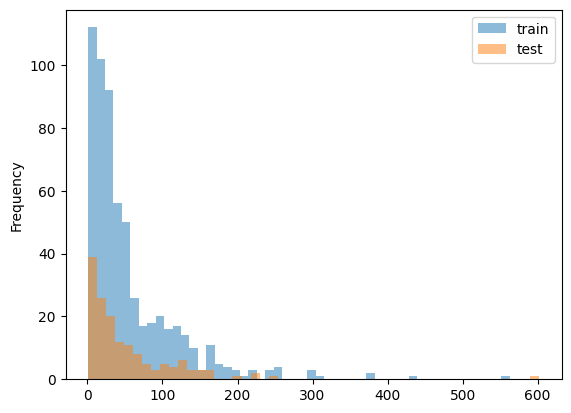

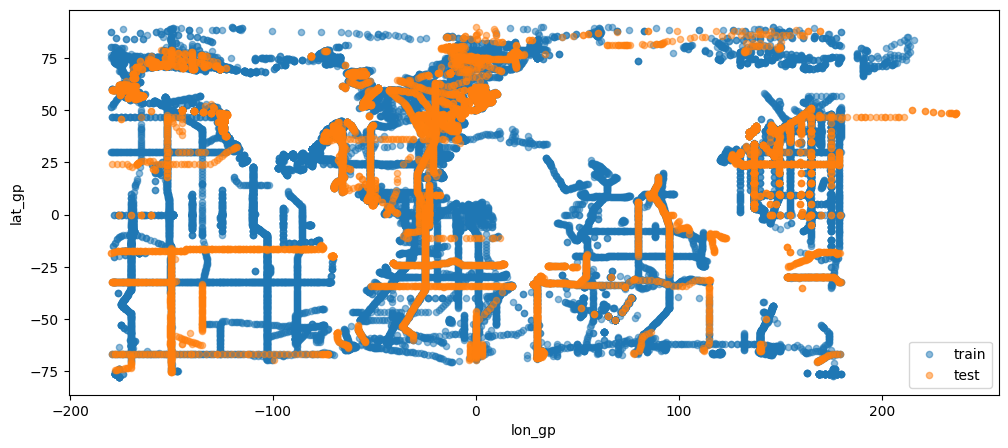

In [11]:
train_expo = set(X.expocode_gp.iloc[train_idx].unique())
test_expo = set(X.expocode_gp.iloc[test_idx].unique())
assert len(train_expo & test_expo) == 0, "can't have overlapping expocodes in train and test sets"

df.iloc[train_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label='train')
df.iloc[test_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label='test')
plt.legend()

split_stats = pd.concat([
    y.iloc[train_idx].value_counts()[salinity_bin_labels],
    y.iloc[test_idx].value_counts()[salinity_bin_labels], 
], axis=1, keys=['train', 'test'])

fig, ax = plt.subplots(figsize=[12, 5])
df.iloc[train_idx].plot(x='lon_gp', y='lat_gp', c="C0", kind='scatter', alpha=0.5, label='train', ax=ax)
df.iloc[test_idx].plot(x='lon_gp', y='lat_gp', c="C1", kind='scatter', alpha=0.5, label='test', ax=ax)
ax.legend()

split_stats

In [16]:
x_train = df.iloc[train_idx]
y_train = df.iloc[train_idx]['talk_gp']

x_test = df.iloc[test_idx]
y_test = df.iloc[test_idx]['talk_gp']

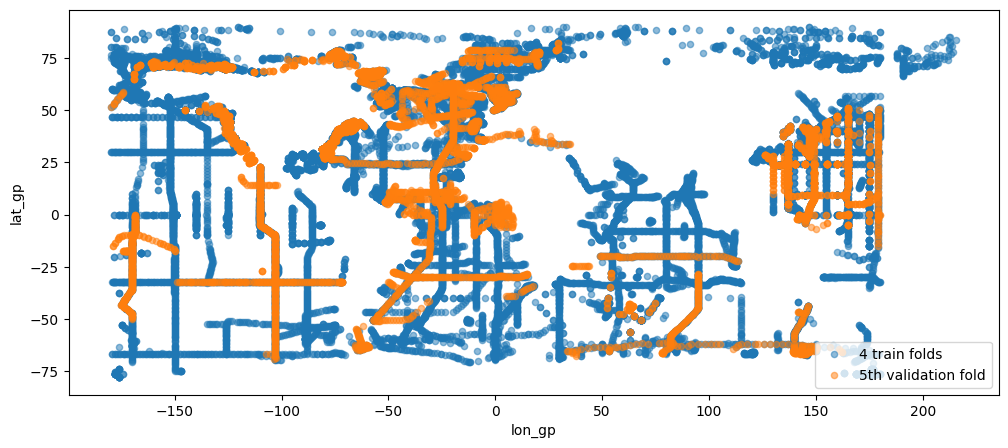

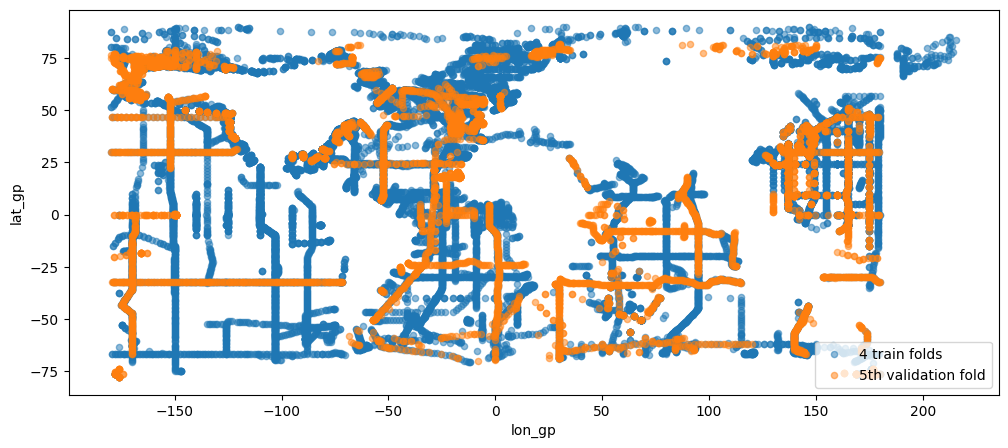

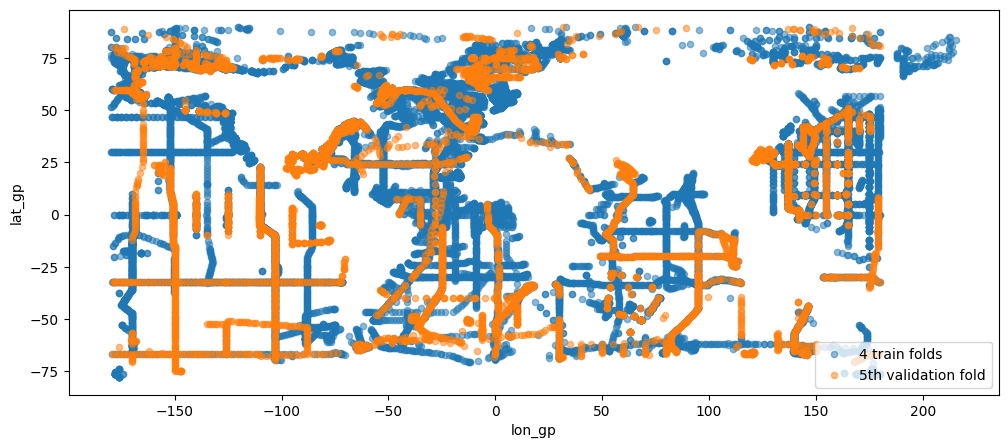

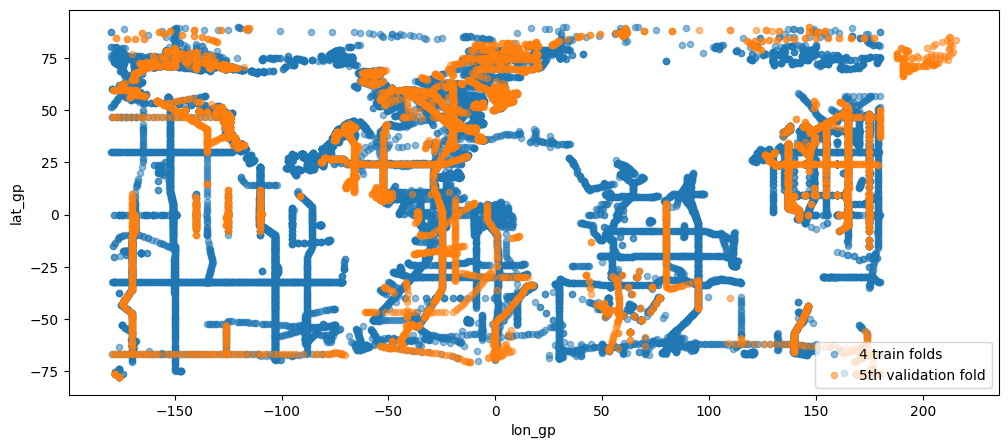

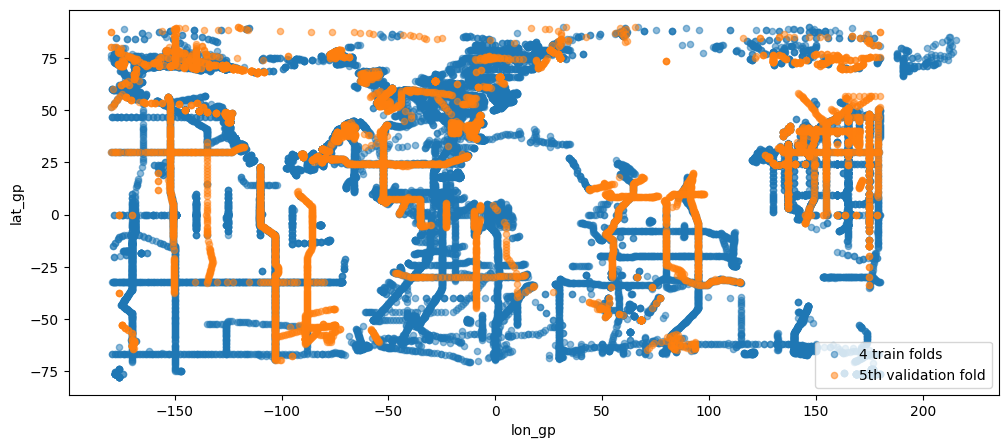

In [ ]:
# Cross validation folds:

cv_splitter = model_selection.StratifiedGroupKFold(n_splits=5)
cv_splits = list(cv_splitter.split(x_train, x_train['salinity_bin'], groups=x_train["expocode_gp"]))


# train_idx, test_idx = next(splits)

# train_expo = set(X.expocode_gp.iloc[train_idx].unique())
# test_expo = set(X.expocode_gp.iloc[test_idx].unique())
# assert len(train_expo & test_expo) == 0, "can't have overlapping expocodes in train and test sets"

# df.iloc[train_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label='train')
# df.iloc[test_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label='test')
# plt.legend()

# split_stats = pd.concat([
#     y.iloc[train_idx].value_counts()[salinity_bin_labels],
#     y.iloc[test_idx].value_counts()[salinity_bin_labels], 
# ], axis=1, keys=['train', 'test'])


for a_cv_split in cv_splits:
    fig, ax = plt.subplots(figsize=[12, 5])

    train_folds_idx, val_fold_ix = a_cv_split

    # Ensure the selections return DataFrames and specify x and y columns explicitly
    x_train.iloc[train_folds_idx].plot.scatter(
        x='lon_gp', y='lat_gp', c="C0", alpha=0.5, label='4 train folds', ax=ax
    )
    x_train.iloc[val_fold_ix].plot.scatter(
        x='lon_gp', y='lat_gp', c="C1", alpha=0.5, label='5th validation fold', ax=ax
    )
    ax.legend()
    plt.show()





In [12]:
drop_cols = (
    ['talk_gp', 'year_gp', 'expocode_gp', 'salinity_bin', 'tco2_gp', 'fco2_gp', 'silicate_gp', 'phtsinsitutp_gp', 'oxygen_gp', 'nitrate_gp', 'nitrite_gp', 'phosphate_gp',  'aou_gp', 'salinity_soda','temp_soda'] 
    + df.filter(regex='time').columns.tolist() 
    + df.filter(regex='lat|lon').columns.tolist() 
    + df.filter(regex='uncert|error').columns.tolist()
    + df.filter(regex='depth').columns.tolist()
    + df.filter(regex='sss').columns.tolist()
    + df.filter(regex='flag').columns.tolist()
    + df.filter(regex='qc').columns.tolist()
)

x_train = x_train.drop(columns=drop_cols)
x_test = x_test.drop(columns=drop_cols)

x_train.to_parquet("X_train.parquet")
x_test.to_parquet("X_test.parquet")
y_train.to_parquet("y_train.parquet")
y_test.to_parquet("y_test.parquet")

In [13]:
x_train.columns

Index(['temp_gp', 'salinity_gp', 'mld_soda', 'sst_cciT', 'ice_cciT',
       'ssh_adt_cmems', 'ssh_sla_cmems', 'mld_glorys', 'chl_globcolour'],
      dtype='str')

# CatBoost

In [2]:
import catboost as cb

In [ ]:
train_pool = cb.Pool(data =x_train, label= y_train )
test_pool = cb.Pool(data = x_test, label =y_test)

# Extract the first validation split from cv_splits
train_indices, val_indices = cv_splits[0]

# Create the eval_set using the validation data
eval_set = [(x_train.iloc[val_indices], y_train.iloc[val_indices])]

# Fit the CatBoost model with eval_set
model = cb.CatBoostRegressor(iterations=10_000)
model.fit(x_train.iloc[train_indices], y_train.iloc[train_indices], eval_set=eval_set, logging_level='Info', plot=True)

# can also be used for categorical features with cat_features = []

# sample_weights = something with qc or flags
# weigthed_train_pool = cb.Pool( x_train, y_train, weights = sample_weights)
# weigthed_test_pool = cb.Pool(x_test, y_test)

In [14]:
yhat_train = model.predict(x_train)
yhat_test = model.predict(x_test)

In [17]:
RMSE = model.eval_metrics(x_train,'RMSE')

CatBoostError: Invalid data type=<class 'pandas.DataFrame'>, must be catboost.Pool.

In [15]:
df_metrics = pd.DataFrame({
    'r2_score': {
        'train': metrics.r2_score(y_train, yhat_train), 
        'test': metrics.r2_score(y_test, yhat_test)
    },
    'rmse': {
        'train': metrics.root_mean_squared_error(y_train, yhat_train), 
        'test': metrics.root_mean_squared_error(y_test, yhat_test)
    },
    'mae': {
        'train': metrics.mean_absolute_error(y_train, yhat_train), 
        'test': metrics.mean_absolute_error(y_test, yhat_test)
    },
    'bias': {
        'train': (yhat_train - y_train).mean(), 
        'test': (yhat_test - y_test).mean()
    }
})

df_metrics.T.round(2)

,train,test
r2_score,0.99,0.89
rmse,12.77,35.31
mae,7.43,12.50
bias,-0.00,0.56


In [16]:
names: list[str] = model.feature_names_  # type: ignore
values = model.feature_importances_

pd.Series({k: float(v) for k, v in zip(names, values, strict=True)}).sort_values(ascending=False)

salinity_gp       72.060954
ssh_adt_cmems      5.941838
mld_glorys         4.844893
chl_globcolour     3.846080
sst_cciT           3.829508
temp_gp            3.380965
ssh_sla_cmems      2.898314
mld_soda           2.668000
ice_cciT           0.529448
dtype: float64

In [ ]:
cv_results = []

for fold, (train_indices, val_indices) in enumerate(cv_splits):
    print(f"Training on fold {fold + 1}/{len(cv_splits)}")
    
    # Split the data into training and validation sets
    X_train_fold = x_train.iloc[train_indices]
    y_train_fold = y_train.iloc[train_indices]
    X_val_fold = x_train.iloc[val_indices]
    y_val_fold = y_train.iloc[val_indices]
    
    # Create the CatBoost model
    model = cb.CatBoostRegressor(iterations=10_000, logging_level='Info')
    
    # Fit the model on the current fold
    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], plot=True)
    
    # Evaluate the model on the validation set
    y_val_pred = model.predict(X_val_fold)
    fold_metrics = {
        'fold': fold + 1,
        'r2_score': metrics.r2_score(y_val_fold, y_val_pred),
        'rmse': metrics.mean_squared_error(y_val_fold, y_val_pred, squared=False),
        'mae': metrics.mean_absolute_error(y_val_fold, y_val_pred)
    }
    cv_results.append(fold_metrics)

# Display cross-validation results
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)
print("Average Metrics:")
print(cv_results_df.mean(numeric_only=True))